In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --- PARAMÈTRES ---
ALPHA = 0.05  # Le "Learning Rate" : définit la vitesse d'apprentissage
ACTIONS = ('REUSSITE', 'ECHEC') # Les deux catégories que le modèle doit apprendre

def max_dict(d):
    """Fonction utilitaire pour trouver la clé avec la plus grande valeur dans un dictionnaire."""
    max_key = None
    max_val = float('-inf')
    for k, v in d.items():
        if v > max_val:
            max_val = v
            max_key = k
    return max_key, max_val

In [7]:
class StudentModel:
    def __init__(self):
        # On initialise 17 poids (theta) aléatoirement.
        # Pourquoi 17 ? (7 variables + 1 biais) * 2 actions = 16. Le +1 est une marge de sécurité.
        self.theta = np.random.randn(17) * 0.1

    def sa2x(self, s, a):
        """Transforme l'état 's' et l'action 'a' en un vecteur de caractéristiques utilisable."""
        x = np.zeros(17)
        # Si c'est 'REUSSITE', on remplit la première moitié du vecteur.
        # Si c'est 'ECHEC', on remplit la seconde (offset de 8).
        offset = 0 if a == 'REUSSITE' else 8
        for i in range(7):
            x[offset + i] = s[i] # On insère les caractéristiques de l'étudiant
        x[offset + 7] = 1 # On ajoute un "biais" (toujours à 1) pour l'ajustement constant
        return x

    def predict(self, s, a):
        """Calcule le score de confiance pour une action donnée via un produit scalaire."""
        return self.theta.dot(self.sa2x(s, a))

    def grad(self, s, a):
        """Définit la direction dans laquelle ajuster les poids (ici, c'est le vecteur d'entrée)."""
        return self.sa2x(s, a)

In [8]:
# --- DATASET DE 20 ÉTUDIANTS ---
# Colonnes : Étude, Sommeil, Stress, Participation, Sport, Écran, Note Finale
raw_data = np.array([

[8, 7, 2, 90, 5, 2, 18], [2, 5, 8, 30, 0, 7, 6], [5, 6, 5, 60, 2, 4, 12], [1, 4, 9, 10, 0, 10, 3],
[9, 8, 1, 95, 4, 1, 19], [3, 5, 7, 40, 1, 6, 7], [6, 7, 4, 75, 3, 3, 14], [4, 6, 6, 50, 2, 5, 9],
[7, 7, 3, 85, 4, 2, 16], [2, 4, 8, 25, 0, 8, 5], [10, 8, 2, 98, 5, 1, 20], [0, 3, 10, 5, 0, 12, 2],
[5, 5, 5, 55, 2, 4, 11], [3, 6, 7, 45, 1, 5, 8], [8, 6, 3, 80, 3, 3, 15], [2, 5, 9, 20, 0, 9, 4],
[6, 8, 3, 70, 6, 2, 13], [4, 7, 5, 65, 3, 4, 10], [9, 7, 2, 92, 4, 2, 17], [1, 5, 8, 15, 1, 7, 5]
])

# Normalisation : On divise tout par le maximum de chaque colonne.
# Cela met toutes les valeurs entre 0 et 1 pour aider le modèle à converger.
max_vals = raw_data.max(axis=0)
data_norm = raw_data / max_vals

In [9]:
model = StudentModel()
deltas = [] # Liste pour stocker l'évolution de l'erreur pour le graphique

for it in range(5000): # On répète l'entraînement 5000 fois (époques)
    biggest_change = 0
    # Décroissance de l'alpha : on apprend vite au début, puis plus précisément à la fin
    alpha = ALPHA / (1 + 0.001 * it)

    # Mélange aléatoire pour que le modèle n'apprenne pas l'ordre des lignes par cœur
    np.random.shuffle(data_norm)

    for s in data_norm:
        # On extrait la note réelle (remise à l'échelle) pour savoir si c'est un succès ou non
        note_reelle = s[6] * max_vals[6]
        vraie_classe = 'REUSSITE' if note_reelle >= 10 else 'ECHEC'

        old_theta = model.theta.copy()

        for a in ACTIONS:
            # Si l'action testée est la bonne, la cible est 1, sinon 0.
            cible = 1.0 if a == vraie_classe else 0.0
            pred = model.predict(s, a) # Ce que l'IA pense actuellement

            # Mise à jour des poids (La règle de Delta) :
            # Nouveau poids = Ancien poids + (Pas * Erreur * Direction)
            model.theta += alpha * (cible - pred) * model.grad(s, a)

        # On enregistre le changement pour voir si le modèle se stabilise
        biggest_change = max(biggest_change, np.abs(model.theta - old_theta).sum())
    deltas.append(biggest_change)

session normale : prédiction vs réalité
note   | réel       | prédiction
12.0   | REUSSITE   | REUSSITE  
18.0   | REUSSITE   | REUSSITE  
10.0   | REUSSITE   | REUSSITE  
16.0   | REUSSITE   | REUSSITE  
7.0    | ECHEC      | ECHEC     
6.0    | ECHEC      | ECHEC     
9.0    | ECHEC      | ECHEC     
11.0   | REUSSITE   | REUSSITE  
19.0   | REUSSITE   | REUSSITE  
15.0   | REUSSITE   | REUSSITE  


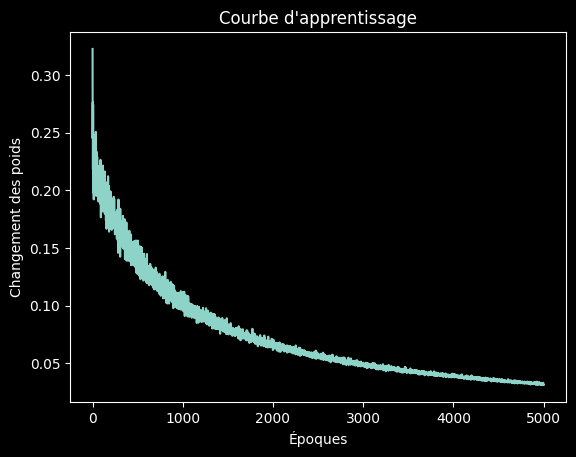

In [13]:
# --- VÉRIFICATION ---
print("session normale : prédiction vs réalité")
print("note   | réel       | prédiction")
for s in data_norm[:10]: # On prend les 10 premiers pour tester
    note = s[6] * max_vals[6]
    reel = 'REUSSITE' if note >= 10 else 'ECHEC'

    # On demande au modèle son score pour les deux catégories
    res = {a: model.predict(s, a) for a in ACTIONS}
    choix, _ = max_dict(res) # On prend celle qui a le score le plus élevé
    print(f"{note:<6.1f} | {reel:<10} | {choix:<10}")

# --- GRAPHIQUE ---
plt.plot(deltas) # Affiche la courbe de convergence
plt.title("Courbe d'apprentissage")
plt.xlabel("Époques")
plt.ylabel("Changement des poids") # Si ça descend vers 0, c'est que la machine a fini d'apprendre
plt.show()